# Defender model first attempt

First attempt at buidling a midfielder model. This is creating a v simple model for midfielders, which I can then build other functions/methods around rather than being state of the art.

## Checklist for notebook
- [X] Filter data to just midfielders
- [ ] Use same features as defenders + goals scored?
- [ ] Create a midfielder experiment in mlflow and train a simple model on initial data 

In [1]:
from matplotlib import pyplot as plt
import mlflow
import polars as pl
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

from fantasy_football.constants import DATA_FOLDER, MODELS_FOLDER, MLFLOW_DB_PATH
from fantasy_football.processors.team_features import merge_team_conceded, merge_team_scored
from fantasy_football.processors.player_features import merge_player_conceded, get_player_rolling_minutes, merge_player_goals_scored, merge_player_assists, merge_player_yellow_cards, merge_player_red_cards
from fantasy_football.processors.gk_features import merge_gk_rolling_saves
from fantasy_football.models.evaluation import PlayerModelMetrics
from fantasy_football.models.utils import save_model, save_pipeline

In [2]:
player_data_filepath = DATA_FOLDER.joinpath("raw","cleaned_merged_seasons.csv")
player_data = pl.read_csv(player_data_filepath, try_parse_dates=True).sort("kickoff_time")

player_data.head()

season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
str,str,str,str,i64,i64,i64,i64,f64,i64,i64,i64,i64,f64,f64,"datetime[μs, UTC]",i64,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,bool,i64,i64
"""2016-17""","""Andrew Robertson""","""DEF""",null,0,0,14,0,1.8,152,4,1,0,1.7,14.8,2016-08-13 11:30:00 UTC,90,8,"""Leicester""",0,0,0,0,1,0,32036,1.0,2.0,0.0,2,0,0,0,45,true,0,1
"""2016-17""","""Benjamin Chilwell""","""DEF""",null,0,0,0,0,0.0,496,4,0,0,0.0,0.0,2016-08-13 11:30:00 UTC,0,7,"""Hull""",0,0,0,0,1,0,8192,1.0,2.0,0.0,0,0,0,0,45,false,0,1
"""2016-17""","""Christian Fuchs""","""DEF""",null,0,0,17,0,13.8,168,4,2,0,5.6,25.4,2016-08-13 11:30:00 UTC,90,7,"""Hull""",0,0,0,0,1,0,418306,1.0,2.0,17.0,0,0,0,0,55,false,1,1
"""2016-17""","""Daniel Amartey""","""DEF""",null,0,0,6,0,10.5,182,4,0,0,1.9,8.0,2016-08-13 11:30:00 UTC,23,7,"""Hull""",0,0,0,0,1,0,2315,1.0,2.0,0.0,1,0,0,0,45,false,0,1
"""2016-17""","""Demarai Gray""","""MID""",null,1,0,16,0,2.9,181,4,2,0,2.2,1.6,2016-08-13 11:30:00 UTC,67,7,"""Hull""",0,0,0,0,1,0,19681,1.0,2.0,17.0,5,0,0,0,50,false,0,1


In [4]:
mid_data = player_data.filter(pl.col("position") == "MID")
mid_data.head()

season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
str,str,str,str,i64,i64,i64,i64,f64,i64,i64,i64,i64,f64,f64,"datetime[μs, UTC]",i64,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,bool,i64,i64
"""2016-17""","""Demarai Gray""","""MID""",null,1,0,16,0,2.9,181,4,2,0,2.2,1.6,2016-08-13 11:30:00 UTC,67,7,"""Hull""",0,0,0,0,1,0,19681,1.0,2.0,17.0,5,0,0,0,50,false,0,1
"""2016-17""","""Jake Livermore""","""MID""",null,0,0,13,0,0.0,157,4,1,0,2.5,25.4,2016-08-13 11:30:00 UTC,90,8,"""Leicester""",0,0,0,0,1,0,4169,1.0,2.0,0.0,2,0,0,0,50,true,0,1
"""2016-17""","""Jarrod Bowen""","""MID""",null,0,0,0,0,0.0,516,4,0,0,0.0,0.0,2016-08-13 11:30:00 UTC,0,8,"""Leicester""",0,0,0,0,1,0,0,1.0,2.0,0.0,0,0,0,0,45,true,0,1
"""2016-17""","""Jeffrey Schlupp""","""MID""",null,0,0,0,0,0.0,169,4,0,0,0.0,0.0,2016-08-13 11:30:00 UTC,0,7,"""Hull""",0,0,0,0,1,0,18404,1.0,2.0,0.0,0,0,0,0,50,false,0,1
"""2016-17""","""Marc Albrighton""","""MID""",null,0,0,0,0,0.0,177,4,0,0,0.0,0.0,2016-08-13 11:30:00 UTC,0,7,"""Hull""",0,0,0,0,1,0,73665,1.0,2.0,0.0,0,0,0,0,55,false,0,1


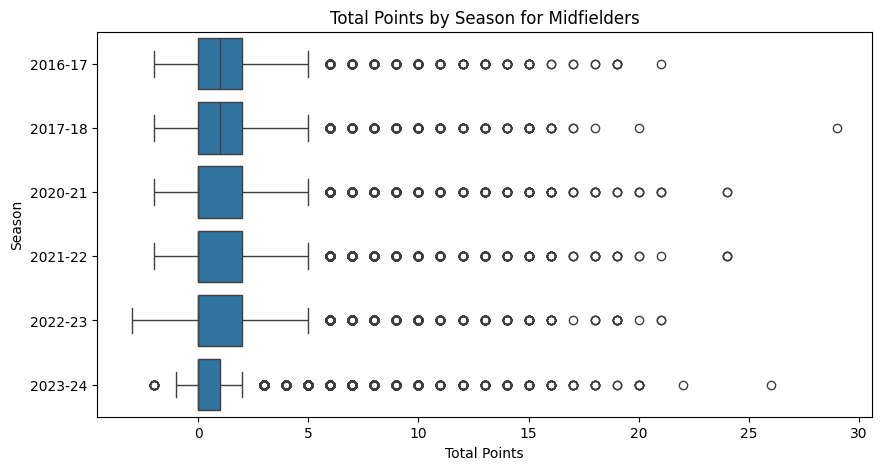

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=mid_data, y="season_x", x="total_points", ax=ax)

ax.set(
    xlabel="Total Points",
    ylabel="Season",
    title="Total Points by Season for Midfielders"
)

plt.show()


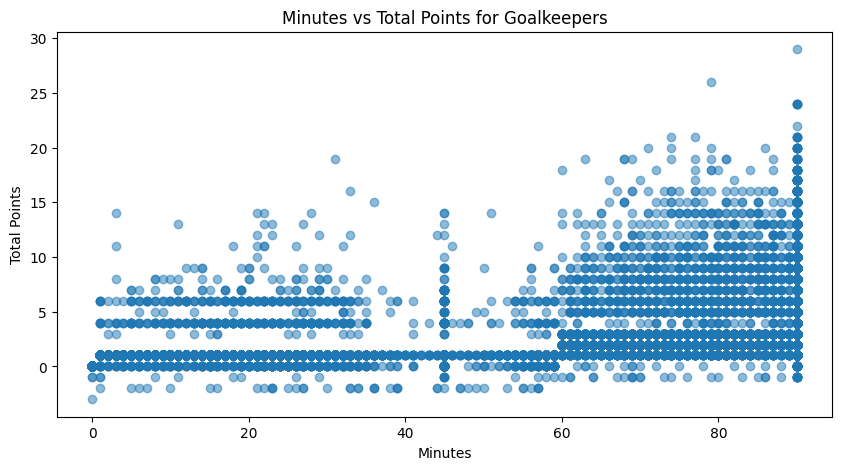

In [6]:
# minutes
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(mid_data["minutes"], mid_data["total_points"], alpha=0.5)

ax.set(
    xlabel="Minutes",
    ylabel="Total Points",
    title="Minutes vs Total Points for Goalkeepers"
)

plt.show()

In [7]:
test = mid_data.select(["name", "kickoff_time", "team_x", "minutes", "goals_conceded", "assists", "goals_scored", "yellow_cards", "red_cards", "opp_team_name", "total_points"])
test = merge_team_conceded(test)
test = merge_player_conceded(test)
test = merge_player_goals_scored(test)
test = merge_player_assists(test)
test = merge_player_yellow_cards(test)
test = merge_player_red_cards(test)
test = get_player_rolling_minutes(test)
test = merge_team_scored(test, by_left="opp_team_name")
test = test.rename({"team_scored_rolling_5": "opponent_team_scored_rolling_5"})
test.tail()

name,kickoff_time,team_x,minutes,goals_conceded,assists,goals_scored,yellow_cards,red_cards,opp_team_name,total_points,team_goals_conceded,team_conceded_rolling_5,goals_conceded_right,player_conceded_rolling_5,player_minutes_rolling_5,minutes_right,goals_scored_right,player_goals_scored_rolling_5,player_minutes_rolling_5_right,assists_right,player_assists_rolling_5,yellow_cards_right,player_yellow_cards_rolling_5,red_cards_right,player_red_cards_rolling_5,team_goals_scored,opponent_team_scored_rolling_5
str,"datetime[μs, UTC]",str,i64,i64,i64,i64,i64,i64,str,i64,i64,f64,i64,f64,f64,i64,i64,f64,i64,i64,f64,i64,f64,i64,f64,i64,f64
"""Jeff Hendrick""",2024-05-19 15:00:00 UTC,"""Newcastle""",0,0,0,0,0,0,"""Brentford""",0,2,1.6,1,2.5,0.0,10,0,1.25,72,0,0.0,0,0.0,0,0.0,2,1.8
"""Andros Townsend""",2024-05-19 15:00:00 UTC,"""Luton""",14,0,0,0,0,0,"""Fulham""",1,4,3.2,0,1.973684,17.4,14,0,0.0,228,0,0.0,0,0.0,0,0.0,4,0.8
"""Jordan Henderson""",2024-05-19 15:00:00 UTC,"""Liverpool""",0,0,0,0,0,0,"""Wolves""",0,0,2.0,1,0.971223,0.0,33,0,0.0,278,0,0.0,0,0.0,0,0.0,0,0.8
"""Daniel Gore""",2024-05-19 15:00:00 UTC,"""Man Utd""",0,0,0,0,0,0,"""Brighton""",0,0,2.0,0,null,0.0,1,0,null,null,0,null,0,null,0,null,0,0.6
"""Braian Ojeda Rodríguez""",2024-05-19 15:00:00 UTC,"""Nott'm Forest""",0,0,0,0,0,0,"""Burnley""",0,1,2.0,null,null,0.0,null,null,null,null,null,null,null,null,null,null,1,1.6


In [8]:
test = test.filter(pl.col("team_x").is_not_null())

In [ ]:
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH}")
mlflow.set_experiment("midfielder_model")

with mlflow.start_run() as run:
    cols_to_drop = [
        "name",
        "kickoff_time",
        "team_x",
        "minutes",
        "goals_conceded",
        "assists",
        "goals_scored",
        "yellow_cards",
        "red_cards",
        "opp_team_name",
        "total_points",
        "team_goals_conceded",
        "goals_conceded_right",
        "minutes_right",
        "goals_scored_right",
        "player_minutes_rolling_5_right",
        "assists_right",
        "yellow_cards_right",
        "red_cards_right",
        "team_goals_scored",
    ]

    x = test.drop(cols_to_drop)
    features = x.columns
    y = test.select(["total_points"])

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    numerical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    numerical_pipeline.fit(x_train)
    x_train = numerical_pipeline.transform(x_train)
    x_test = numerical_pipeline.transform(x_test)

    numerical_pipeline_path = MODELS_FOLDER.joinpath("numerical_pipeline.pkl")
    save_pipeline(numerical_pipeline, numerical_pipeline_path)
    
    model = LinearRegression()
    model.fit(x_train, y_train)

    model_path = MODELS_FOLDER.joinpath("linear_regression.pkl")
    save_model(model, model_path)

    y_pred = model.predict(x_test)

    metrics = PlayerModelMetrics(y_test, y_pred)
    metrics.metrics_report()

    mlflow.log_params(model.get_params())
    mlflow.log_params({"features": features})
    mlflow.log_metrics(metrics.metrics_report())
    mlflow.log_artifact(str(numerical_pipeline_path))
    mlflow.sklearn.log_model(
        sk_model=model,  # Your trained model object
        artifact_path="model",  # Path within the MLflow run's artifact store
        registered_model_name="defender_linear_regression"  # Optional: register in model registry
    )
